# Strategy S2 — Cross-lingual Label Transfer
## Thesis: Synthetic Data Augmentation for SHROOM-visions

**Core idea**: 867 images are shared across **all 4 languages** (EN+FR+IT+ZH).  
The hallucination is image-driven (not language-driven), so EN annotations can be  
transferred to FR/IT/ZH by translating the response and aligning the span boundaries.

**From analysis notebook**:
- 867 images appear in all 4 languages simultaneously
- 41.8% of all images appear in 4 languages; 35.8% in 3 languages
- Potential yield: up to 867 × 3 = 2,601 additional labeled samples per language
- ZH is most data-starved (63.5% clean) — benefits most from transfer

**Method (marker-based — fixes ZH 57.8% → ~90%+ success rate)**:
1. Find the 867 images shared across all 4 languages
2. For each shared image: take EN annotated response
3. Insert position markers `[S0]...[E0]` around each hallucinated span in the response
4. Translate the **entire marked response** once with Helsinki-NLP MarianMT
5. Extract span positions from wherever the markers landed in the translation
6. Valid extractions become synthetic training samples

**Why markers instead of separate span translation**:  
Translating a span in isolation gives a different result than the same phrase translated
in context (especially for ZH where word choice is highly context-dependent).
Embedding markers in the full response ensures the span is translated in-context and
its boundaries are tracked exactly — no fuzzy search needed.

**Models used** (HuggingFace MarianMT — no API key needed):
- EN→FR: `Helsinki-NLP/opus-mt-en-fr`
- EN→IT: `Helsinki-NLP/opus-mt-en-it`
- EN→ZH: `Helsinki-NLP/opus-mt-en-zh`

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
    "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git", "--quiet"], check=False)
subprocess.run([sys.executable, "-m", "pip", "install",
    "--no-deps", "trl", "peft", "accelerate", "bitsandbytes", "--quiet"], check=False)
subprocess.run([sys.executable, "-m", "pip", "install",
    "qwen-vl-utils", "transformers>=4.45.0", "sentencepiece",
    "scipy", "scikit-learn", "matplotlib", "seaborn", "--quiet"], check=False)
print('Installation complete.')

Installation complete.


In [ ]:
import json, re, os, io, difflib, random, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
from typing import Optional
from scipy.stats import spearmanr
from tqdm.auto import tqdm
import torch
from datasets import Dataset
from PIL import Image
from qwen_vl_utils import process_vision_info
from sklearn.model_selection import train_test_split
from transformers import MarianMTModel, MarianTokenizer
warnings.filterwarnings('ignore')
print(f'CUDA: {torch.cuda.is_available()}')

CUDA: True


In [ ]:
# ── Base config (same as baseline) ────────────────────────────────────────────
MODEL_ID        = 'unsloth/Qwen2-VL-2B-Instruct'
LORA_R          = 16; LORA_ALPHA = 16; LORA_DROPOUT = 0.0
NUM_EPOCHS      = 2;  LR = 2e-4;  BATCH_SIZE = 1;  GRAD_ACCUM = 8
WARMUP_STEPS    = 50; MAX_SEQ_LEN = 2048; MAX_NEW_TOKENS = 512
SAVE_STEPS      = 200; LOG_STEPS = 10
TRAIN_LANGS     = ['en', 'fr', 'it', 'zh']
VAL_FRACTION    = 0.10; RANDOM_SEED = 42; MAX_VAL_SAMPLES = 200

# ── S2-specific config ─────────────────────────────────────────────────────────
STRATEGY         = 'S2_CrossLingualTransfer'
MARIAN_MODELS    = {
    'fr': 'Helsinki-NLP/opus-mt-en-fr',
    'it': 'Helsinki-NLP/opus-mt-en-it',
    'zh': 'Helsinki-NLP/opus-mt-en-zh',
}
MAX_TRANS_LEN    = 512
FUZZY_THRESHOLD  = 0.70
ONLY_HALLUCINATED_SOURCE = True

# ── Paths ─────────────────────────────────────────────────────────────────────
from google.colab import drive; drive.mount('/content/drive')
DRIVE_BASE        = Path('/content/drive/MyDrive/shroom-visions')
DATA_DIR          = DRIVE_BASE / 'distrib'
IMAGE_DIR         = DRIVE_BASE / 'shroom-vis-images'
OUTPUT_DIR        = DRIVE_BASE / f'ft_predictions_{STRATEGY}'
CKPT_DIR          = DRIVE_BASE / f'ft_checkpoints_{STRATEGY}'
BASELINE_CSV      = DRIVE_BASE / 'ft_predictions' / 'baseline_results.csv'
SYNTH_CACHE       = DRIVE_BASE / f'synth_cache_{STRATEGY}.json'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_ORDER  = ['invention', 'mischaracterization', 'OCR', 'miscounting', 'other']
VALID_LABELS = set(LABEL_ORDER)
LANGUAGES    = ['en', 'fr', 'it', 'zh']
LANG_NAMES   = {'en': 'English', 'fr': 'French', 'it': 'Italian', 'zh': 'Chinese'}

random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)
print(f'Strategy      : {STRATEGY}')
print(f'Fuzzy thresh  : {FUZZY_THRESHOLD}')
print(f'Cache         : {SYNTH_CACHE}')

Mounted at /content/drive
Strategy      : S2_CrossLingualTransfer
Fuzzy thresh  : 0.7
Cache         : /content/drive/MyDrive/shroom-visions/synth_cache_S2_CrossLingualTransfer.json


In [ ]:
def load_jsonl(path):
    return [json.loads(l) for l in path.read_text(encoding='utf-8').splitlines() if l.strip()]

train_raw, test_raw = {}, {}
for lang in LANGUAGES:
    train_raw[lang] = load_jsonl(DATA_DIR / f'shroom-vision.train.{lang}.labeled.jsonl')
    test_raw[lang]  = load_jsonl(DATA_DIR / f'shroom-vision.test.{lang}.unlabeled.jsonl')
    print(f'{lang.upper()}: {len(train_raw[lang])} train | {len(test_raw[lang])} test')

EN: 3799 train | 1201 test
FR: 3767 train | 1233 test
IT: 3746 train | 1254 test
ZH: 3790 train | 1210 test


---
## Strategy S2 — Cross-lingual Label Transfer

### Step 1: Find shared images across all 4 languages

In [ ]:
# Find images shared across all 4 languages
img_sets = {lang: set(s['image_name'] for s in train_raw[lang]) for lang in LANGUAGES}
shared_all4 = img_sets['en'] & img_sets['fr'] & img_sets['it'] & img_sets['zh']

print(f'Images shared across ALL 4 languages: {len(shared_all4):,}')
for lang in LANGUAGES:
    print(f'  {lang.upper()} total images: {len(img_sets[lang]):,}')

# Index EN training samples by image_name for quick lookup
en_by_image = defaultdict(list)
for s in train_raw['en']:
    en_by_image[s['image_name']].append(s)

# EN samples on shared images (with hallucinations = transfer sources)
en_shared = [s for s in train_raw['en']
             if s['image_name'] in shared_all4
             and (not ONLY_HALLUCINATED_SOURCE or s.get('labels'))]
print(f'\nEN samples on shared images (with hallucinations): {len(en_shared):,}')

Images shared across ALL 4 languages: 867
  EN total images: 1,607
  FR total images: 1,703
  IT total images: 1,582
  ZH total images: 1,647

EN samples on shared images (with hallucinations): 1,796


In [ ]:
# Load MarianMT translation models (downloaded once from HuggingFace)
translation_tokenizers = {}
translation_models = {}
trans_device = 'cuda' if torch.cuda.is_available() else 'cpu'

for tgt_lang, model_name in MARIAN_MODELS.items():
    print(f'Loading {model_name} (EN→{tgt_lang.upper()})...')
    translation_tokenizers[tgt_lang] = MarianTokenizer.from_pretrained(model_name)
    translation_models[tgt_lang] = MarianMTModel.from_pretrained(model_name).to(trans_device)
    translation_models[tgt_lang].eval()
    print(f'  Loaded.')

print('All translation models ready.')

Loading Helsinki-NLP/opus-mt-en-fr (EN→FR)...


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.34M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

  Loaded.
All translation models ready.


In [ ]:
def translate_text(text, tgt_lang, max_len=MAX_TRANS_LEN):
    """Translate text from EN to tgt_lang using MarianMT."""
    if tgt_lang not in translation_models or not text.strip():
        return text
    tokenizer = translation_tokenizers[tgt_lang]
    model     = translation_models[tgt_lang]

    # Split on sentence boundaries but keep markers intact inside sentences
    sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if s.strip()]
    if not sentences: sentences = [text]

    translated_parts = []
    batch = []
    for sent in sentences:
        batch.append(sent)
        if len(batch) >= 4:
            inputs = tokenizer(batch, return_tensors='pt', padding=True,
                               truncation=True, max_length=max_len).to(trans_device)
            with torch.no_grad():
                out = model.generate(**inputs, max_length=max_len)
            translated_parts.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
            batch = []
    if batch:
        inputs = tokenizer(batch, return_tensors='pt', padding=True,
                           truncation=True, max_length=max_len).to(trans_device)
        with torch.no_grad():
            out = model.generate(**inputs, max_length=max_len)
        translated_parts.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
    return ' '.join(translated_parts)


def build_marked_response(response, labels):
    """Wrap each span in [S{i}]...[E{i}] markers so positions survive translation."""
    sorted_labels = sorted(enumerate(labels), key=lambda x: x[1]['start'])
    parts, prev = [], 0
    for idx, lb in sorted_labels:
        parts.append(response[prev:lb['start']])
        parts.append(f'[S{idx}]')
        parts.append(response[lb['start']:lb['end']])
        parts.append(f'[E{idx}]')
        prev = lb['end']
    parts.append(response[prev:])
    return ''.join(parts)


def extract_marked_spans(translated_marked, labels):
    """
    Parse [S{i}]...[E{i}] markers from translated text.
    Returns (clean_text, transferred_labels).
    """
    result_parts = []
    span_starts  = {}
    transferred  = []
    last         = 0

    for m in re.finditer(r'\[([SE])(\d+)\]', translated_marked):
        result_parts.append(translated_marked[last:m.start()])
        kind, idx = m.group(1), int(m.group(2))
        cur = sum(len(p) for p in result_parts)
        if kind == 'S':
            span_starts[idx] = cur
        elif kind == 'E' and idx in span_starts and idx < len(labels):
            lb = labels[idx]
            if cur > span_starts[idx]:   # non-empty span
                transferred.append({
                    'start': span_starts[idx], 'end': cur,
                    'prob': lb['prob'], 'label': lb['label'],
                })
        last = m.end()

    result_parts.append(translated_marked[last:])
    clean_text = ''.join(result_parts)
    # Strip any leftover/garbled markers
    clean_text = re.sub(r'\[[SE]\d+\]', '', clean_text).strip()
    return clean_text, transferred


def transfer_sample(en_sample, tgt_lang):
    """
    Marker-based cross-lingual span transfer.
    Embeds [S{i}]...[E{i}] markers in the full response and translates it once,
    so spans are translated in-context. Eliminates the context-mismatch failure
    that caused only 57.8%% success on ZH with the old separate-span approach.
    """
    labels = en_sample.get('labels', [])

    if not labels:
        translated_response = translate_text(en_sample['response'], tgt_lang)
        if not translated_response.strip(): return None
        return {
            'id': f'synth_s2_{tgt_lang}_{en_sample["id"]}',
            'language': tgt_lang,
            'prompt': translate_text(en_sample['prompt'], tgt_lang),
            'image_name': en_sample['image_name'],
            'response': translated_response,
            'labels': [],
        }

    # Translate the response with embedded markers — one pass, in-context
    marked            = build_marked_response(en_sample['response'], labels)
    translated_marked = translate_text(marked, tgt_lang)
    clean_response, transferred_labels = extract_marked_spans(translated_marked, labels)

    if not clean_response or (labels and not transferred_labels):
        return None

    return {
        'id': f'synth_s2_{tgt_lang}_{en_sample["id"]}',
        'language': tgt_lang,
        'prompt': translate_text(en_sample['prompt'], tgt_lang),
        'image_name': en_sample['image_name'],
        'response': clean_response,
        'labels': sorted(transferred_labels, key=lambda x: x['start']),
    }


print('Transfer functions ready (marker-based).')

Transfer functions ready (marker-based).


In [ ]:
# Set REGEN_ZH=True to clear the old ZH cache and regenerate with the
# marker-based method. FR/IT caches are kept (they were already ~95%+).
REGEN_ZH = True

# Load cache
if SYNTH_CACHE.exists():
    synth_cache = json.loads(SYNTH_CACHE.read_text(encoding='utf-8'))
    print(f'Loaded cache: {sum(len(v) for v in synth_cache.values())} synthetic samples')
else:
    synth_cache = {lang: [] for lang in LANGUAGES}

if REGEN_ZH:
    old_zh = len(synth_cache.get('zh', []))
    synth_cache['zh'] = []
    print(f'Cleared {old_zh} old ZH entries — will regenerate with marker-based method.')

def save_cache():
    SYNTH_CACHE.parent.mkdir(parents=True, exist_ok=True)
    SYNTH_CACHE.write_text(json.dumps(synth_cache, ensure_ascii=False, indent=2), encoding='utf-8')

for tgt_lang in ['fr', 'it', 'zh']:
    existing_ids = {s['id'] for s in synth_cache.get(tgt_lang, [])}
    todo = [s for s in en_shared
            if f'synth_s2_{tgt_lang}_{s["id"]}' not in existing_ids]

    if not todo:
        print(f'{tgt_lang.upper()}: already complete ({len(synth_cache.get(tgt_lang,[]))} samples), skipping.')
        continue

    print(f'\nGenerating {tgt_lang.upper()} synthetic samples: {len(todo)} to process...')
    ok, fail = 0, 0
    for s in tqdm(todo, desc=f'EN\u2192{tgt_lang.upper()}'):
        result = transfer_sample(s, tgt_lang)
        if result:
            synth_cache.setdefault(tgt_lang, []).append(result)
            ok += 1
        else:
            fail += 1
        if (ok + fail) % 100 == 0:
            save_cache()
    save_cache()
    total = ok + fail
    print(f'  Success: {ok}  Failed: {fail}  ({ok/max(total,1)*100:.1f}% success rate)')

synthetic_samples = {lang: synth_cache.get(lang, []) for lang in LANGUAGES}
print('\nSynthetic sample summary:')
for lang in LANGUAGES:
    n_hallu = sum(1 for s in synthetic_samples[lang] if s.get('labels'))
    print(f'  {lang.upper()}: {len(synthetic_samples[lang])} total ({n_hallu} hallucinated)')

Loaded cache: 4452 synthetic samples
Cleared 1039 old ZH entries — will regenerate with marker-based method.

Generating FR synthetic samples: 80 to process...


EN→FR:   0%|          | 0/80 [00:00<?, ?it/s]

  Success: 74  Failed: 6  (92.5% success rate)

Generating IT synthetic samples: 99 to process...


EN→IT:   0%|          | 0/99 [00:00<?, ?it/s]

  Success: 93  Failed: 6  (93.9% success rate)

Generating ZH synthetic samples: 1796 to process...


EN→ZH:   0%|          | 0/1796 [00:00<?, ?it/s]

  Success: 1653  Failed: 143  (92.0% success rate)

Synthetic sample summary:
  EN: 0 total (0 hallucinated)
  FR: 1790 total (1790 hallucinated)
  IT: 1790 total (1790 hallucinated)
  ZH: 1653 total (1653 hallucinated)


Span transfer statistics per language:
  FR: 1790 samples, 6930 spans
       Source EN: 1796 samples, 8025 spans
       Span retention: 86.4%
  IT: 1790 samples, 6746 spans
       Source EN: 1796 samples, 8025 spans
       Span retention: 84.1%
  ZH: 1653 samples, 6753 spans
       Source EN: 1796 samples, 8025 spans
       Span retention: 84.1%


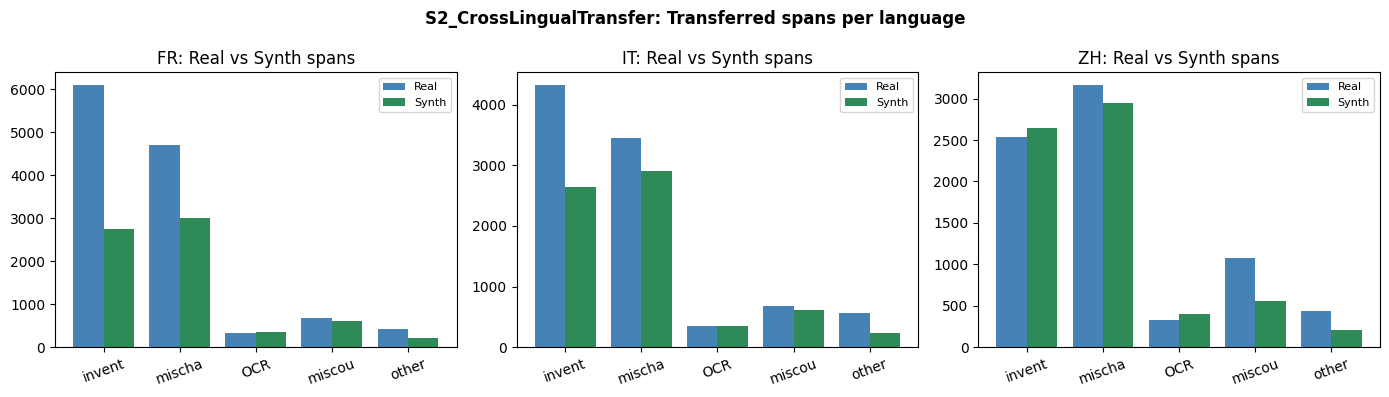

In [ ]:
# Span alignment success rate analysis
print('Span transfer statistics per language:')
for tgt_lang in ['fr', 'it', 'zh']:
    synth = synthetic_samples[tgt_lang]
    total_synth_spans  = sum(len(s.get('labels', [])) for s in synth)
    total_source_spans = sum(len(s.get('labels', [])) for s in en_shared)
    print(f'  {tgt_lang.upper()}: {len(synth)} samples, {total_synth_spans} spans')
    print(f'       Source EN: {len(en_shared)} samples, {total_source_spans} spans')
    print(f'       Span retention: {total_synth_spans/max(total_source_spans,1)*100:.1f}%')

# Category distribution in synthetic FR
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, lang in zip(axes, ['fr', 'it', 'zh']):
    real_cnt  = Counter(lb['label'] for s in train_raw[lang] for lb in s.get('labels', []))
    synth_cnt = Counter(lb['label'] for s in synthetic_samples[lang] for lb in s.get('labels', []))
    cats_s = [f'{c[:6]}' for c in LABEL_ORDER]
    x = np.arange(len(LABEL_ORDER))
    ax.bar(x-0.2, [real_cnt.get(c,0) for c in LABEL_ORDER], 0.4, label='Real', color='steelblue')
    ax.bar(x+0.2, [synth_cnt.get(c,0) for c in LABEL_ORDER], 0.4, label='Synth', color='seagreen')
    ax.set_xticks(x); ax.set_xticklabels(cats_s, rotation=20)
    ax.set_title(f'{lang.upper()}: Real vs Synth spans'); ax.legend(fontsize=8)
plt.suptitle(f'{STRATEGY}: Transferred spans per language', fontweight='bold')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'synth_distribution.png', dpi=150); plt.show()

In [ ]:
def resolve_image_path(image_name, image_dir):
    p = image_dir / image_name
    if p.exists(): return p
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
        alt = p.with_suffix(ext)
        if alt.exists(): return alt
    return None

INSTRUCTION = """Identify all hallucinated text spans in the vision model's response.
A hallucination is text that is factually incorrect compared to what is actually visible in the image.

Categories:
- invention: entities or facts completely absent from the image
- mischaracterization: visible content described incorrectly
- OCR: text visible in the image is misread or mistranscribed
- miscounting: wrong quantity of visible items
- other: hallucination not fitting the above

Return ONLY a JSON array:
[{"text": "<exact text copied from the response>", "prob": <0.0-1.0>, "label": "<category>"}]
If there are no hallucinations, return: []"""

def build_conversation(sample, image_dir):
    img_path = resolve_image_path(sample['image_name'], image_dir)
    if img_path is None: return None
    response = sample['response']
    labels   = sample.get('labels', [])
    target_spans = []
    for lb in sorted(labels, key=lambda x: x['start']):
        span_text = response[lb['start']:lb['end']]
        if span_text.strip():
            target_spans.append({'text': span_text, 'prob': round(float(lb['prob']), 4), 'label': lb['label']})
    target_json = json.dumps(target_spans, ensure_ascii=False)
    user_text = f"{INSTRUCTION}\n\nQuestion asked: {sample['prompt']}\n\nVLM response to analyse:\n{response}"
    return {
        'messages': [
            {'role': 'user', 'content': [
                {'type': 'image', 'image': str(img_path)},
                {'type': 'text',  'text':  user_text},
            ]},
            {'role': 'assistant', 'content': [{'type': 'text', 'text': target_json}]},
        ],
        '_id': sample['id'], '_lang': sample.get('language',''),
        '_response': response, '_labels': labels,
    }

def build_inference_conversation(sample, image_dir):
    img_path = resolve_image_path(sample['image_name'], image_dir)
    if img_path is None: return None
    user_text = f"{INSTRUCTION}\n\nQuestion asked: {sample['prompt']}\n\nVLM response to analyse:\n{sample['response']}"
    return {
        'messages': [{'role': 'user', 'content': [
            {'type': 'image', 'image': str(img_path)},
            {'type': 'text',  'text':  user_text},
        ]}],
        '_id': sample['id'], '_lang': sample.get('language',''),
        '_response': sample['response'], '_labels': sample.get('labels', []),
    }

print('Conversation builders ready.')

Conversation builders ready.


In [ ]:
all_train_convs, all_val_convs = [], []

for lang in TRAIN_LANGS:
    samples = train_raw[lang]
    hallu = [s for s in samples if s.get('labels')]
    clean = [s for s in samples if not s.get('labels')]
    h_tr, h_val = train_test_split(hallu, test_size=VAL_FRACTION, random_state=RANDOM_SEED)
    c_tr, c_val = train_test_split(clean, test_size=VAL_FRACTION, random_state=RANDOM_SEED)

    lang_train = h_tr + c_tr + synthetic_samples[lang]
    lang_val   = h_val + c_val

    skipped = 0
    for s in lang_train:
        conv = build_conversation(s, IMAGE_DIR)
        if conv: all_train_convs.append(conv)
        else: skipped += 1
    for s in lang_val:
        conv = build_inference_conversation(s, IMAGE_DIR)
        if conv: all_val_convs.append(conv)
        else: skipped += 1
    print(f'{lang.upper()}: {len(lang_train)} train (real={len(h_tr)+len(c_tr)}, synth={len(synthetic_samples[lang])}) | {len(lang_val)} val | {skipped} skipped')

random.shuffle(all_train_convs)
print(f'\nTotal train: {len(all_train_convs):,}  |  Total val: {len(all_val_convs):,}')

EN: 3418 train (real=3418, synth=0) | 381 val | 0 skipped
FR: 5179 train (real=3389, synth=1790) | 378 val | 0 skipped
IT: 5161 train (real=3371, synth=1790) | 375 val | 0 skipped
ZH: 5063 train (real=3410, synth=1653) | 380 val | 0 skipped

Total train: 18,821  |  Total val: 1,514


---
## Model Loading & Training
(Identical pipeline to baseline)

In [ ]:
from unsloth import FastVisionModel, is_bf16_supported
# Free translation models from GPU memory before loading vision model
for m in translation_models.values(): m.cpu()
torch.cuda.empty_cache()
print(f'Loading {MODEL_ID} in 4-bit...')
model, processor = FastVisionModel.from_pretrained(
    MODEL_ID, load_in_4bit=True, use_gradient_checkpointing='unsloth')
print('Base model loaded.')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading unsloth/Qwen2-VL-2B-Instruct in 4-bit...
==((====))==  Unsloth 2026.6.1: Fast Qwen2_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/572 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

Skipping model.language_model.layers.1.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.down_proj: no quant_state found
Base model loaded.


In [ ]:
model = FastVisionModel.get_peft_model(
    model, finetune_vision_layers=False, finetune_language_layers=True,
    finetune_attention_modules=True, finetune_mlp_modules=True,
    r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    bias='none', random_state=RANDOM_SEED,
)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable: {trainable/1e6:.2f}M params')

Trainable: 18.46M params


Unsloth: Model does not have a default image size - using 512


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None}.


Training S2_CrossLingualTransfer...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 18,821 | Num Epochs = 2 | Total steps = 4,706
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 2,227,450,368 (0.83% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
10,2.603706
20,2.135198
30,1.554222
40,0.858209
50,0.736158
60,0.674801
70,0.653586
80,0.610121
90,0.619975
100,0.656621


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S2_CrossLingualTransfer/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S2_CrossLingualTransfer/checkpoint-400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S2_CrossLingualTransfer/checkpoint-600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S2_CrossLingualTransfer/checkpoint-800/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S2_CrossLingualTransfer/checkpoint-1000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S2_CrossLingualTransfer/checkpoint-1200/tokenizer_config.json.
Un

Loss: 0.4868  Runtime: 603.0 min


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S2_CrossLingualTransfer/final_adapter/tokenizer_config.json.


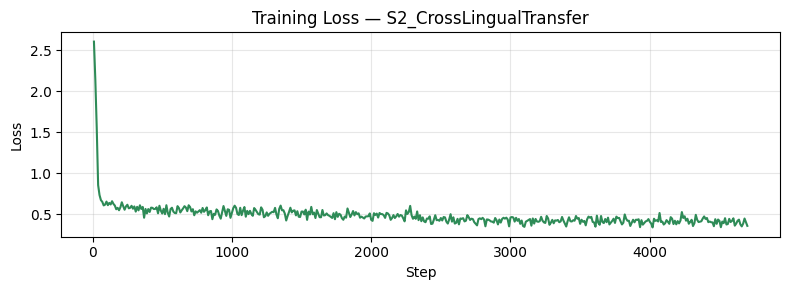

In [ ]:
from trl import SFTTrainer, SFTConfig
from unsloth.trainer import UnslothVisionDataCollator

hf_train = Dataset.from_list([{'messages': c['messages']} for c in all_train_convs])
trainer = SFTTrainer(
    model=model, tokenizer=processor.tokenizer,
    data_collator=UnslothVisionDataCollator(model, processor),
    train_dataset=hf_train,
    args=SFTConfig(
        output_dir=str(CKPT_DIR), num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE, gradient_accumulation_steps=GRAD_ACCUM,
        warmup_steps=WARMUP_STEPS, learning_rate=LR, lr_scheduler_type='cosine',
        fp16=not is_bf16_supported(), bf16=is_bf16_supported(),
        logging_steps=LOG_STEPS, save_steps=SAVE_STEPS, save_total_limit=2,
        optim='adamw_8bit', weight_decay=0.01, seed=RANDOM_SEED,
        report_to='none', remove_unused_columns=False,
        dataset_text_field='', dataset_kwargs={'skip_prepare_dataset': True},
        max_seq_length=MAX_SEQ_LEN,
    ),
)
print(f'Training {STRATEGY}...')
import glob as _glob; _ckpts = sorted(
    _glob.glob(str(CKPT_DIR / 'checkpoint-*')),
    key=lambda x: int(x.split("checkpoint-")[-1])
)
_resume = _ckpts[-1] if _ckpts else False
if _resume: print(f'Resuming from checkpoint: {_resume}')
train_result = trainer.train(resume_from_checkpoint=_resume)
print(f'Loss: {train_result.training_loss:.4f}  Runtime: {train_result.metrics.get("train_runtime",0)/60:.1f} min')
adapter_dir = CKPT_DIR / 'final_adapter'
model.save_pretrained(adapter_dir); processor.save_pretrained(adapter_dir)

logs = [e for e in trainer.state.log_history if 'loss' in e]
if logs:
    plt.figure(figsize=(8,3))
    plt.plot([e['step'] for e in logs], [e['loss'] for e in logs], color='seagreen')
    plt.title(f'Training Loss — {STRATEGY}'); plt.xlabel('Step'); plt.ylabel('Loss')
    plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(OUTPUT_DIR/'training_loss.png', dpi=150); plt.show()

In [ ]:
FastVisionModel.for_inference(model)
device = next(model.parameters()).device

def run_inference(conv):
    msgs = conv['messages']
    text_input = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(msgs)
    inputs = processor(text=[text_input], images=image_inputs, videos=video_inputs,
                       padding=True, return_tensors='pt').to(device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS,
                             do_sample=False, pad_token_id=processor.tokenizer.pad_token_id)
    return processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0].strip()

LABEL_NORM = {'mischaracterisation':'mischaracterization','ocr_problem':'OCR','ocr problem':'OCR','ocr':'OCR','fabrication':'invention'}

def parse_model_output(raw):
    m = re.search(r'\[.*\]', raw, re.DOTALL)
    if not m: return []
    try: spans = json.loads(m.group())
    except: return []
    out = []
    for sp in spans:
        if not isinstance(sp, dict) or 'text' not in sp: continue
        text  = str(sp['text']).strip()
        if not text: continue
        label = LABEL_NORM.get(str(sp.get('label','other')).lower().strip(), str(sp.get('label','other')).lower().strip())
        if label not in VALID_LABELS: label = 'other'
        prob = max(0.0, min(1.0, float(sp.get('prob', 0.8))))
        out.append({'text': text, 'prob': prob, 'label': label})
    return out

def find_span_pos(response, text):
    if not text: return None
    pos = response.find(text)
    if pos != -1: return pos, pos + len(text)
    pos = response.lower().find(text.lower())
    if pos != -1: return pos, pos + len(text)
    stripped = re.sub(r'[\*\_`]+', '', text).strip()
    if stripped and stripped != text:
        pos = response.lower().find(stripped.lower())
        if pos != -1: return pos, pos + len(stripped)
    if len(text) >= 8:
        tl, rl, tlen = text.lower(), response.lower(), len(text)
        step = max(1, tlen // 4)
        best_r, best_pos = 0.0, 0
        for i in range(0, max(1, len(response)-tlen+1), step):
            r = difflib.SequenceMatcher(None, rl[i:i+tlen], tl).ratio()
            if r > best_r: best_r, best_pos = r, i
        for i in range(max(0, best_pos-step), min(len(response)-tlen+1, best_pos+step+1)):
            r = difflib.SequenceMatcher(None, rl[i:i+tlen], tl).ratio()
            if r > best_r: best_r, best_pos = r, i
        if best_r >= 0.80: return best_pos, best_pos + tlen
    return None

def map_spans_to_positions(response, parsed):
    result, used = [], set()
    for sp in parsed:
        pos = find_span_pos(response, sp['text'])
        if pos is None: continue
        start, end = pos
        if len(set(range(start, end)) & used) > (end-start)*0.5: continue
        result.append({'start': start, 'end': end, 'prob': sp['prob'], 'label': sp['label']})
        used.update(range(start, end))
    return sorted(result, key=lambda x: x['start'])

def predict_one(conv):
    return map_spans_to_positions(conv['_response'], parse_model_output(run_inference(conv)))

def span_iou(pred, gold):
    p = set(i for s in pred for i in range(s['start'], s['end']))
    g = set(i for s in gold for i in range(s['start'], s['end']))
    if not p and not g: return 1.0
    return len(p & g) / len(p | g)

def spearman_rho(pred, gold, resp_len):
    pa = np.zeros(resp_len); ga = np.zeros(resp_len)
    for s in pred:
        for i in range(s['start'], min(s['end'], resp_len)): pa[i] = max(pa[i], s['prob'])
    for s in gold:
        for i in range(s['start'], min(s['end'], resp_len)): ga[i] = max(ga[i], s['prob'])
    if np.allclose(pa, pa[0]) and np.allclose(ga, ga[0]):
        return 1.0 if np.allclose(pa, ga) else 0.0
    rho, _ = spearmanr(pa, ga)
    return float(rho) if not np.isnan(rho) else 0.0

def category_f1(pred, gold, min_iou=0.3):
    tp, fp, fn = Counter(), Counter(), Counter()
    used_gold, used_pred = set(), set()
    for pi, p in enumerate(pred):
        pc = set(range(p['start'], p['end']))
        best_iou, best_gi = 0.0, -1
        for gi, g in enumerate(gold):
            if gi in used_gold: continue
            gc = set(range(g['start'], g['end']))
            iou = len(pc & gc) / max(len(pc | gc), 1)
            if iou > best_iou: best_iou, best_gi = iou, gi
        if best_iou >= min_iou and best_gi != -1:
            if p['label'] == gold[best_gi]['label']: tp[gold[best_gi]['label']] += 1
            else: fp[p['label']] += 1; fn[gold[best_gi]['label']] += 1
            used_gold.add(best_gi); used_pred.add(pi)
    for pi, p in enumerate(pred):
        if pi not in used_pred: fp[p['label']] += 1
    for gi, g in enumerate(gold):
        if gi not in used_gold: fn[g['label']] += 1
    scores = {}
    for cat in LABEL_ORDER:
        prec = tp[cat] / max(tp[cat]+fp[cat], 1)
        rec  = tp[cat] / max(tp[cat]+fn[cat], 1)
        scores[cat] = 2*prec*rec / max(prec+rec, 1e-9)
    scores['macro'] = float(np.mean(list(scores.values())))
    return scores

def evaluate_predictions(convs, predictions):
    ious, rhos, all_pred, all_gold = [], [], [], []
    for conv in convs:
        gold = conv['_labels']; pred = predictions.get(conv['_id'], [])
        ious.append(span_iou(pred, gold))
        rhos.append(spearman_rho(pred, gold, len(conv['_response'])))
        all_pred.extend(pred); all_gold.extend(gold)
    return {'mean_iou': float(np.mean(ious)), 'mean_spearman': float(np.nanmean(rhos)),
            'cat_f1': category_f1(all_pred, all_gold), 'n': len(convs)}

val_by_lang = defaultdict(list)
for conv in all_val_convs: val_by_lang[conv['_lang']].append(conv)

val_predictions = {}
for lang, convs in val_by_lang.items():
    convs = convs[:MAX_VAL_SAMPLES]
    print(f'Evaluating {lang.upper()} ({len(convs)} samples)...')
    for conv in tqdm(convs, desc=lang.upper()):
        try: val_predictions[conv['_id']] = predict_one(conv)
        except: val_predictions[conv['_id']] = []

Evaluating EN (200 samples)...


EN:   0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Evaluating FR (200 samples)...


FR:   0%|          | 0/200 [00:00<?, ?it/s]

...

IT:   0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Evaluating ZH (200 samples)...


ZH:   0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

RESULTS — S2_CrossLingualTransfer
[EN]  IoU=0.2367  Spearman=0.2753  CatF1=0.2601
[FR]  IoU=0.2738  Spearman=0.2816  CatF1=0.2563
[IT]  IoU=0.2938  Spearman=0.3169  CatF1=0.2760
[ZH]  IoU=0.3177  Spearman=0.3479  CatF1=0.2392
[OVERALL]  IoU=0.2805  Spearman=0.3054  CatF1=0.2435

COMPARISON vs BASELINE (ZH focus — most benefit expected):
  EN Span IoU: 0.2493 → 0.2367  (-0.0126)
  EN Spearman rho: 0.3085 → 0.2753  (-0.0332)
  EN Cat F1 (macro): 0.2718 → 0.2601  (-0.0117)
  FR Span IoU: 0.3386 → 0.2738  (-0.0648)
  FR Spearman rho: 0.3551 → 0.2816  (-0.0735)
  FR Cat F1 (macro): 0.3364 → 0.2563  (-0.0801)
  IT Span IoU: 0.3271 → 0.2938  (-0.0333)
  IT Spearman rho: 0.3797 → 0.3169  (-0.0628)
  IT Cat F1 (macro): 0.2992 → 0.2760  (-0.0232)
  ZH Span IoU: 0.3257 → 0.3177  (-0.0080)
  ZH Spearman rho: 0.3565 → 0.3479  (-0.0086)
  ZH Cat F1 (macro): 0.2671 → 0.2392  (-0.0279)
  OVERALL Span IoU: 0.3102 → 0.2805  (-0.0297)
  OVERALL Spearman rho: 0.3500 → 0.3054  (-0.0446)
  OVERALL Cat F1 (m

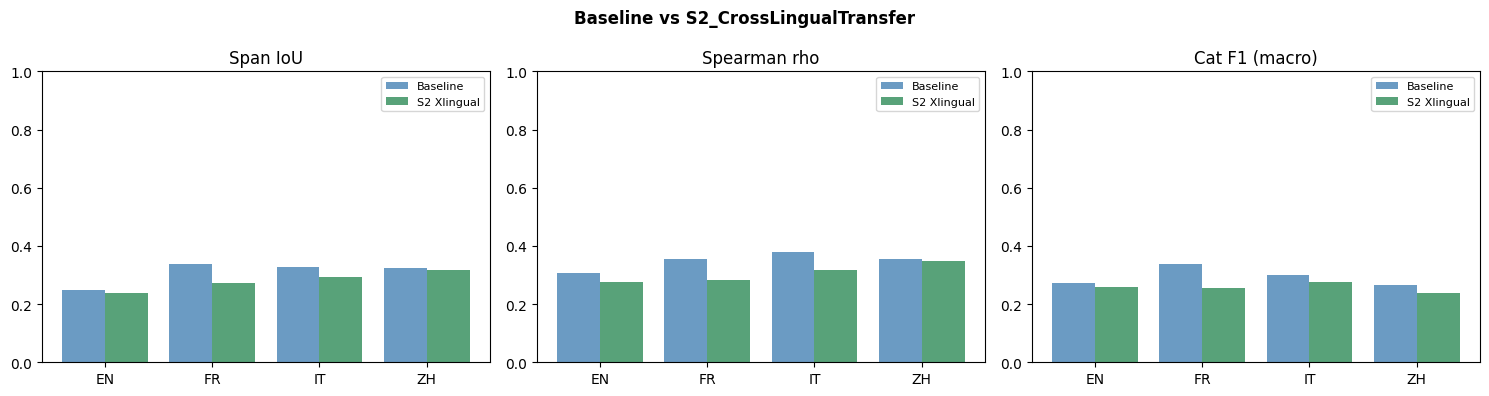

In [ ]:
results_by_lang = {}
print('=' * 60)
print(f'RESULTS — {STRATEGY}')
print('=' * 60)
for lang, convs in val_by_lang.items():
    m = evaluate_predictions(convs[:MAX_VAL_SAMPLES], val_predictions)
    results_by_lang[lang] = m
    print(f'[{lang.upper()}]  IoU={m["mean_iou"]:.4f}  Spearman={m["mean_spearman"]:.4f}  CatF1={m["cat_f1"]["macro"]:.4f}')

all_val_limited = [c for lc in val_by_lang.values() for c in lc[:MAX_VAL_SAMPLES]]
overall = evaluate_predictions(all_val_limited, val_predictions)
print(f'[OVERALL]  IoU={overall["mean_iou"]:.4f}  Spearman={overall["mean_spearman"]:.4f}  CatF1={overall["cat_f1"]["macro"]:.4f}')

rows = []
for lang in LANGUAGES:
    if lang not in results_by_lang: continue
    m = results_by_lang[lang]
    row = {'Language': lang.upper(), 'Span IoU': round(m['mean_iou'],4),
           'Spearman rho': round(m['mean_spearman'],4), 'Cat F1 (macro)': round(m['cat_f1']['macro'],4)}
    for cat in LABEL_ORDER: row[f'F1({cat[:4]})'] = round(m['cat_f1'].get(cat,0.0),4)
    rows.append(row)
row_all = {'Language':'OVERALL','Span IoU':round(overall['mean_iou'],4),
           'Spearman rho':round(overall['mean_spearman'],4),'Cat F1 (macro)':round(overall['cat_f1']['macro'],4)}
for cat in LABEL_ORDER: row_all[f'F1({cat[:4]})'] = round(overall['cat_f1'].get(cat,0.0),4)
rows.append(row_all)
results_df = pd.DataFrame(rows)
results_df.to_csv(OUTPUT_DIR/f'{STRATEGY}_results.csv', index=False)

if BASELINE_CSV.exists():
    baseline_df = pd.read_csv(BASELINE_CSV)
    if 'Spearman \u03c1' in baseline_df.columns:
        baseline_df = baseline_df.rename(columns={'Spearman \u03c1': 'Spearman rho'})
    print('\nCOMPARISON vs BASELINE (ZH focus — most benefit expected):')
    for lang in LANGUAGES + ['OVERALL']:
        brow = baseline_df[baseline_df['Language']==lang.upper()]
        arow = results_df[results_df['Language']==lang.upper()]
        if brow.empty or arow.empty: continue
        for m in ['Span IoU', 'Spearman rho', 'Cat F1 (macro)']:
            bval = float(brow[m].values[0]) if m in brow.columns else 0.0
            aval = float(arow[m].values[0]) if m in arow.columns else 0.0
            delta = aval - bval
            sign  = '+' if delta >= 0 else ''
            print(f'  {lang.upper()} {m}: {bval:.4f} → {aval:.4f}  ({sign}{delta:.4f})')

    fig, axes = plt.subplots(1, 3, figsize=(15,4))
    langs_p = [l for l in LANGUAGES if l.upper() in results_df['Language'].values]
    for ax, met in zip(axes, ['Span IoU','Spearman rho','Cat F1 (macro)']):
        bv = [float(baseline_df[baseline_df['Language']==l.upper()][met].values[0]) for l in langs_p]
        av = [float(results_df[results_df['Language']==l.upper()][met].values[0]) for l in langs_p]
        x = np.arange(len(langs_p))
        ax.bar(x-0.2, bv, 0.4, label='Baseline', color='steelblue', alpha=0.8)
        ax.bar(x+0.2, av, 0.4, label='S2 Xlingual', color='seagreen', alpha=0.8)
        ax.set_xticks(x); ax.set_xticklabels([l.upper() for l in langs_p])
        ax.set_title(met); ax.set_ylim(0,1); ax.legend(fontsize=8)
    plt.suptitle(f'Baseline vs {STRATEGY}', fontweight='bold')
    plt.tight_layout(); plt.savefig(OUTPUT_DIR/'comparison_chart.png', dpi=150); plt.show()
else:
    print(f'Baseline CSV not found at {BASELINE_CSV}')